In [7]:
from boututils.datafile import DataFile
from boutdata.collect import collect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys, pathlib
import platform
import traceback
import xarray as xr
import xbout
from pathlib import Path
import xhermes as xh

sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/sdtool_load_test/sdtools"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/transients"))
sys.path.append(os.path.join(r"/users/jlb647/scratch/simulation_program/hermes-3_sim/analysis/my_notebooks/notebooks/hermes-3/general_functions"))


from plotting_functions import *
from convergence_functions import * 

from hermes3.case_db import *
from hermes3.casedeck import*
from hermes3.load import *
from hermes3.named_selections import *
from hermes3.plotting import *
from hermes3.grid_fields import *
from hermes3.accessors import *
from hermes3.utils import *
from hermes3.fluxes import *
from hermes3.selectors import *
from hermes3.front_tracking import *
from hermes3.neutral_transport import *
# from hermes3.balance1d import *

# plt.style.use('ggplot')
plt.rcParams.update({'font.size': 10})
linewidth = 3
markersize = 15



# plt.style.use('ggplot')
mpl.style.use('default')
mpl.rcParams["axes.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 1
mpl.rcParams['xtick.labelsize'] = 18
mpl.rcParams['ytick.labelsize'] = 18
mpl.rcParams['axes.grid'] = True
mpl.rcParams.update({'font.size': 16})



%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# I/O

In [8]:
parent_dir = '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/'
powers = ['50%', '100%', '300%']
models = ['FL', 'SNB']

# to_load = ['/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/300%_fluence/power_and_density/FL/case_01',
#            '/users/jlb647/scratch/simulation_program/hermes-3_sim/simulation_dir/2024-11_week11_production/power_pulse/300%_fluence/power_only/FL/case_01'
#             ]

cs = dict()

for power in powers:
    for model in models:
        name = f"{power}_{model}"
        cs[name] = Load.case_1D(parent_dir + f"{power}_fluence/power_and_density/{model}/case_01", guard_replace = False, use_squash=True)

# for power in powers:
#     name = f"{power}_FL_power_only"
#     print(f"Loading {name}")
#     cs[name] = Load.case_1D(parent_dir + f"{power}_fluence/power_only/FL/case_01", guard_replace = False, use_squash=True)
# # names = ['power_and_density', 'power_only']



# for index,i in enumerate(to_load):
#     i = Path(i)
#     name = f"{names[index]}"
#     print(f"Loading {name}")
#     cs[name] = Load.case_1D(i, guard_replace = False, use_squash=True)

print(cs.keys())

- Looking for squash file
- Squash file found. squash date 04/23/2025, 19:23:18, dmp file date 11/26/2024, 05:37:12
Skipping unnormalisation
- Looking for squash file
- Squash file found. squash date 04/16/2025, 18:02:03, dmp file date 11/26/2024, 05:59:49
Skipping unnormalisation
- Looking for squash file
- Squash file found. squash date 04/23/2025, 19:38:22, dmp file date 11/26/2024, 05:37:45
Skipping unnormalisation
- Looking for squash file
- Squash file found. squash date 05/09/2025, 13:03:46, dmp file date 11/26/2024, 06:05:39
Skipping unnormalisation
- Looking for squash file
- Squash file found. squash date 04/23/2025, 20:04:43, dmp file date 11/26/2024, 06:50:17
Skipping unnormalisation
- Looking for squash file
- Squash file found. squash date 04/16/2025, 18:30:00, dmp file date 11/26/2024, 06:31:16
Skipping unnormalisation
dict_keys(['50%_FL', '50%_SNB', '100%_FL', '100%_SNB', '300%_FL', '300%_SNB'])


In [9]:
ds  = cs['100%_FL'].ds

# Code from https://github.com/mikekryjak/sdtools/blob/main/hermes3/neutral_transport.py

In [ ]:
def calculate_neutral_mfp_1d(ds, sigma_D_D=6e-19, time_index=-1):
    """
    Calculate 1D neutral mean free paths along spatial coordinate 'pos'
    For deuterium neutrals (D-D elastic collisions)
    
    Parameters:
    -----------
    ds : xarray Dataset
        Dataset containing plasma variables
    sigma_D_D : float, optional
        Deuterium-deuterium elastic collision cross-section in m^2
        Default: 6e-19 m^2 (ESTIMATED - should be validated experimentally)
    time_index : int, optional
        Time index to select for 1D analysis. Default: -1 (last time)
        
        NOTE: This value is an estimate based on scaling from hydrogen.
        Direct experimental measurements of D-D atomic collision cross-sections
        at plasma-relevant energies are limited in the literature.
        
        To determine a better value:
        - Compare with measured neutral transport coefficients
        - Use kinetic theory with measured viscosity data
        - Validate against experimental neutral mean free path measurements
        - Typical range: 3e-19 to 1e-18 m^2
    """
    
    # Select specific time index for 1D analysis
    ds = ds.isel(t=time_index)  
    Ta = ds["Td"].values
    Ti = ds["Td+"].values
    Ne = ds["Ne"].values
    Na = ds["Nd"].values 
    # print(Na)
    Vi = ds["Vd+"]
    Va = ds["NVd"] / (ds["Nd"] * constants("mass_p")*2)

    # Calculate charge exchange collision frequency
    ln_sigmav = -18.5028
    Teff = (Ta + Ti)/2
    lnT = np.log(Teff)
    lnT_n = lnT.copy()

    for b in [0.3708409, 7.949876e-3, -6.143769e-4, -4.698969e-4, -4.096807e-4, 1.440382e-4, -1.514243e-5, 5.122435e-7]:
        ln_sigmav += b * lnT_n
        lnT_n *= lnT
        
    nu_cx = np.exp(ln_sigmav) * 1e-6 * Ne # convert from cm^3/s to m^3/s
    nu = nu_cx  # Only consider CX for ion-neutral collisions
    
    # Calculate thermal velocities
    v_thi = np.sqrt((ds["Td+"]*constants("q_e")) / (constants("mass_p")*2))
    v_thn = np.sqrt((ds["Td"]*constants("q_e")) / (constants("mass_p")*2))

    # Neutral-neutral collision frequency (Deuterium-Deuterium)
    # Using the adjustable cross-section parameter
    nu_nn = Na * sigma_D_D * np.sqrt(2) * v_thn  # Collision frequency [1/s]

    # For 1D case, velocities are just the values (no geometric transformation needed)
    Vi_spatial = Vi
    Va_spatial = Va

    # Calculate temperature gradient along 'pos' dimension
    L_T_spatial = ds["Td+"].differentiate('pos')  # Use xarray's differentiate along 'pos'

    # Calculate mean free paths
    mfp_thermal = (v_thi + v_thn) / nu  # Ion-neutral thermal MFP
    mfp_convective = abs(Vi_spatial - Va_spatial) / nu  # Ion-neutral convective MFP
    mfp_nn = 1 / (Na * sigma_D_D * np.sqrt(2))  # D-D elastic collision MFP

    # Calculate inverse Knudsen numbers (L_T/mfp) and system Knudsen numbers (L_system/mfp)
    Kn_inv_thermal = abs(L_T_spatial) / mfp_thermal
    Kn_inv_convective = abs(L_T_spatial) / mfp_convective
    Kn_inv_nn = abs(L_T_spatial) / mfp_nn  # Deuterium-deuterium inverse Knudsen number
    
    # Calculate system length (total domain size) - ensure it's a scalar
    pos = ds['pos']  # Your spatial coordinate
    L_system = float(pos.max() - pos.min())  # Total system length as scalar
    
    # System Knudsen numbers (L_system/mfp)
    Kn_system_thermal = L_system / mfp_thermal
    Kn_system_convective = L_system / mfp_convective  
    Kn_system_nn = L_system / mfp_nn
    
    # 1D plotting - Knudsen number comparison
    fig1, axes1 = plt.subplots(2, 3, figsize=(15, 8), dpi=150)
    
    # Top row: Temperature scale inverse Knudsen numbers (L_T/mfp)
    axes1[0,0].semilogy(pos, Kn_inv_thermal, 'b-', linewidth=2)
    axes1[0,0].set_title(r"D$^+$-D Thermal: $L_T/mfp$")
    axes1[0,0].set_xlabel("Position")
    axes1[0,0].set_ylabel("$L_T$/mfp")
    axes1[0,0].grid(True, alpha=0.3)
    
    axes1[0,1].semilogy(pos, Kn_inv_convective, 'r-', linewidth=2)
    axes1[0,1].set_title(r"D$^+$-D Convective: $L_T/mfp$")
    axes1[0,1].set_xlabel("Position")
    axes1[0,1].set_ylabel("$L_T$/mfp")
    axes1[0,1].grid(True, alpha=0.3)
    
    axes1[0,2].semilogy(pos, Kn_inv_nn, 'g-', linewidth=2)
    axes1[0,2].set_title(f"D-D: $L_T/mfp$")
    axes1[0,2].set_xlabel("Position")
    axes1[0,2].set_ylabel("$L_T$/mfp")
    axes1[0,2].grid(True, alpha=0.3)
    
    # Bottom row: System scale Knudsen numbers (L_system/mfp)
    axes1[1,0].semilogy(pos, Kn_system_thermal, 'b--', linewidth=2)
    axes1[1,0].set_title(r"D$^+$-D Thermal: $L_{sys}/mfp$")
    axes1[1,0].set_xlabel("Position")
    axes1[1,0].set_ylabel("$L_{system}$/mfp")
    axes1[1,0].grid(True, alpha=0.3)
    
    axes1[1,1].semilogy(pos, Kn_system_convective, 'r--', linewidth=2)
    axes1[1,1].set_title(r"D$^+$-D Convective: $L_{sys}/mfp$")
    axes1[1,1].set_xlabel("Position")
    axes1[1,1].set_ylabel("$L_{system}$/mfp")
    axes1[1,1].grid(True, alpha=0.3)
    
    axes1[1,2].semilogy(pos, Kn_system_nn, 'g--', linewidth=2)
    axes1[1,2].set_title(f"D-D: $L_{{sys}}/mfp$")
    axes1[1,2].set_xlabel("Position")
    axes1[1,2].set_ylabel("$L_{system}$/mfp")
    axes1[1,2].grid(True, alpha=0.3)
    
    # fig1.suptitle(f"Knudsen Number Comparison (L_sys = {L_system:.2f} m)")
    fig1.tight_layout()
    
    # Second figure - Mean free paths
    fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4), dpi=150)

    # Plot mean free paths
    axes2[0].semilogy(pos, mfp_thermal, 'b-', linewidth=2)
    axes2[0].set_title("$mfp_{D^+-D,thermal}$")
    axes2[0].set_xlabel("Position")
    axes2[0].set_ylabel("Mean Free Path [m]")
    axes2[0].grid(True, alpha=0.3)
    
    axes2[1].semilogy(pos, mfp_convective, 'r-', linewidth=2)
    axes2[1].set_title(r"$mfp_{D^+-D,convective}$")
    axes2[1].set_xlabel("Position")
    axes2[1].set_ylabel("Mean Free Path [m]")
    axes2[1].grid(True, alpha=0.3)
    
    axes2[2].semilogy(pos, mfp_nn, 'g-', linewidth=2)
    axes2[2].set_title(f"$mfp_{{D-D}}$")
    axes2[2].set_xlabel("Position")
    axes2[2].set_ylabel("Mean Free Path [m]")
    axes2[2].grid(True, alpha=0.3)
    
    fig2.suptitle("Deuterium Mean Free Paths")
    fig2.tight_layout()
    
    # Print cross-section info for transparency
    print(f"Used D-D collision cross-section: {sigma_D_D:.2e} m²")
    print(f"System length: {L_system:.2f} m")
    print("NOTE: D-D cross-section is an estimated value. For better accuracy:")
    print("1. Compare results with experimental neutral transport data")
    print("2. Adjust sigma_D_D parameter based on validation")
    print("3. Typical range: 3e-19 to 1e-18 m²")
    print("Usage: calculate_neutral_mfp_1d(ds, sigma_D_D=5e-19)")
    
    # Return the calculated quantities for further analysis
    # return {
    #     'mfp_thermal': mfp_thermal,
    #     'mfp_convective': mfp_convective,
    #     'mfp_D_D': mfp_nn,
    #     'Kn_inv_thermal': Kn_inv_thermal,        # L_T/mfp (temperature scale)
    #     'Kn_inv_convective': Kn_inv_convective,  # L_T/mfp 
    #     'Kn_inv_D_D': Kn_inv_nn,               # L_T/mfp
    #     'Kn_system_thermal': Kn_system_thermal,     # L_system/mfp (system scale)
    #     'Kn_system_convective': Kn_system_convective, # L_system/mfp
    #     'Kn_system_D_D': Kn_system_nn,            # L_system/mfp
    #     'position': pos,
    #     'L_system': L_system,                    # Total system length
    #     'L_T_scale': abs(L_T_spatial),          # Temperature gradient scale length
    #     'sigma_D_D_used': sigma_D_D,            # Record the cross-section value used
    #     'sigma_D_D_note': 'ESTIMATED value - validate experimentally'
    # }

Used D-D collision cross-section: 6.00e-19 m²
System length: 82.62 m
NOTE: D-D cross-section is an estimated value. For better accuracy:
1. Compare results with experimental neutral transport data
2. Adjust sigma_D_D parameter based on validation
3. Typical range: 3e-19 to 1e-18 m²
Usage: calculate_neutral_mfp_1d(ds, sigma_D_D=5e-19)


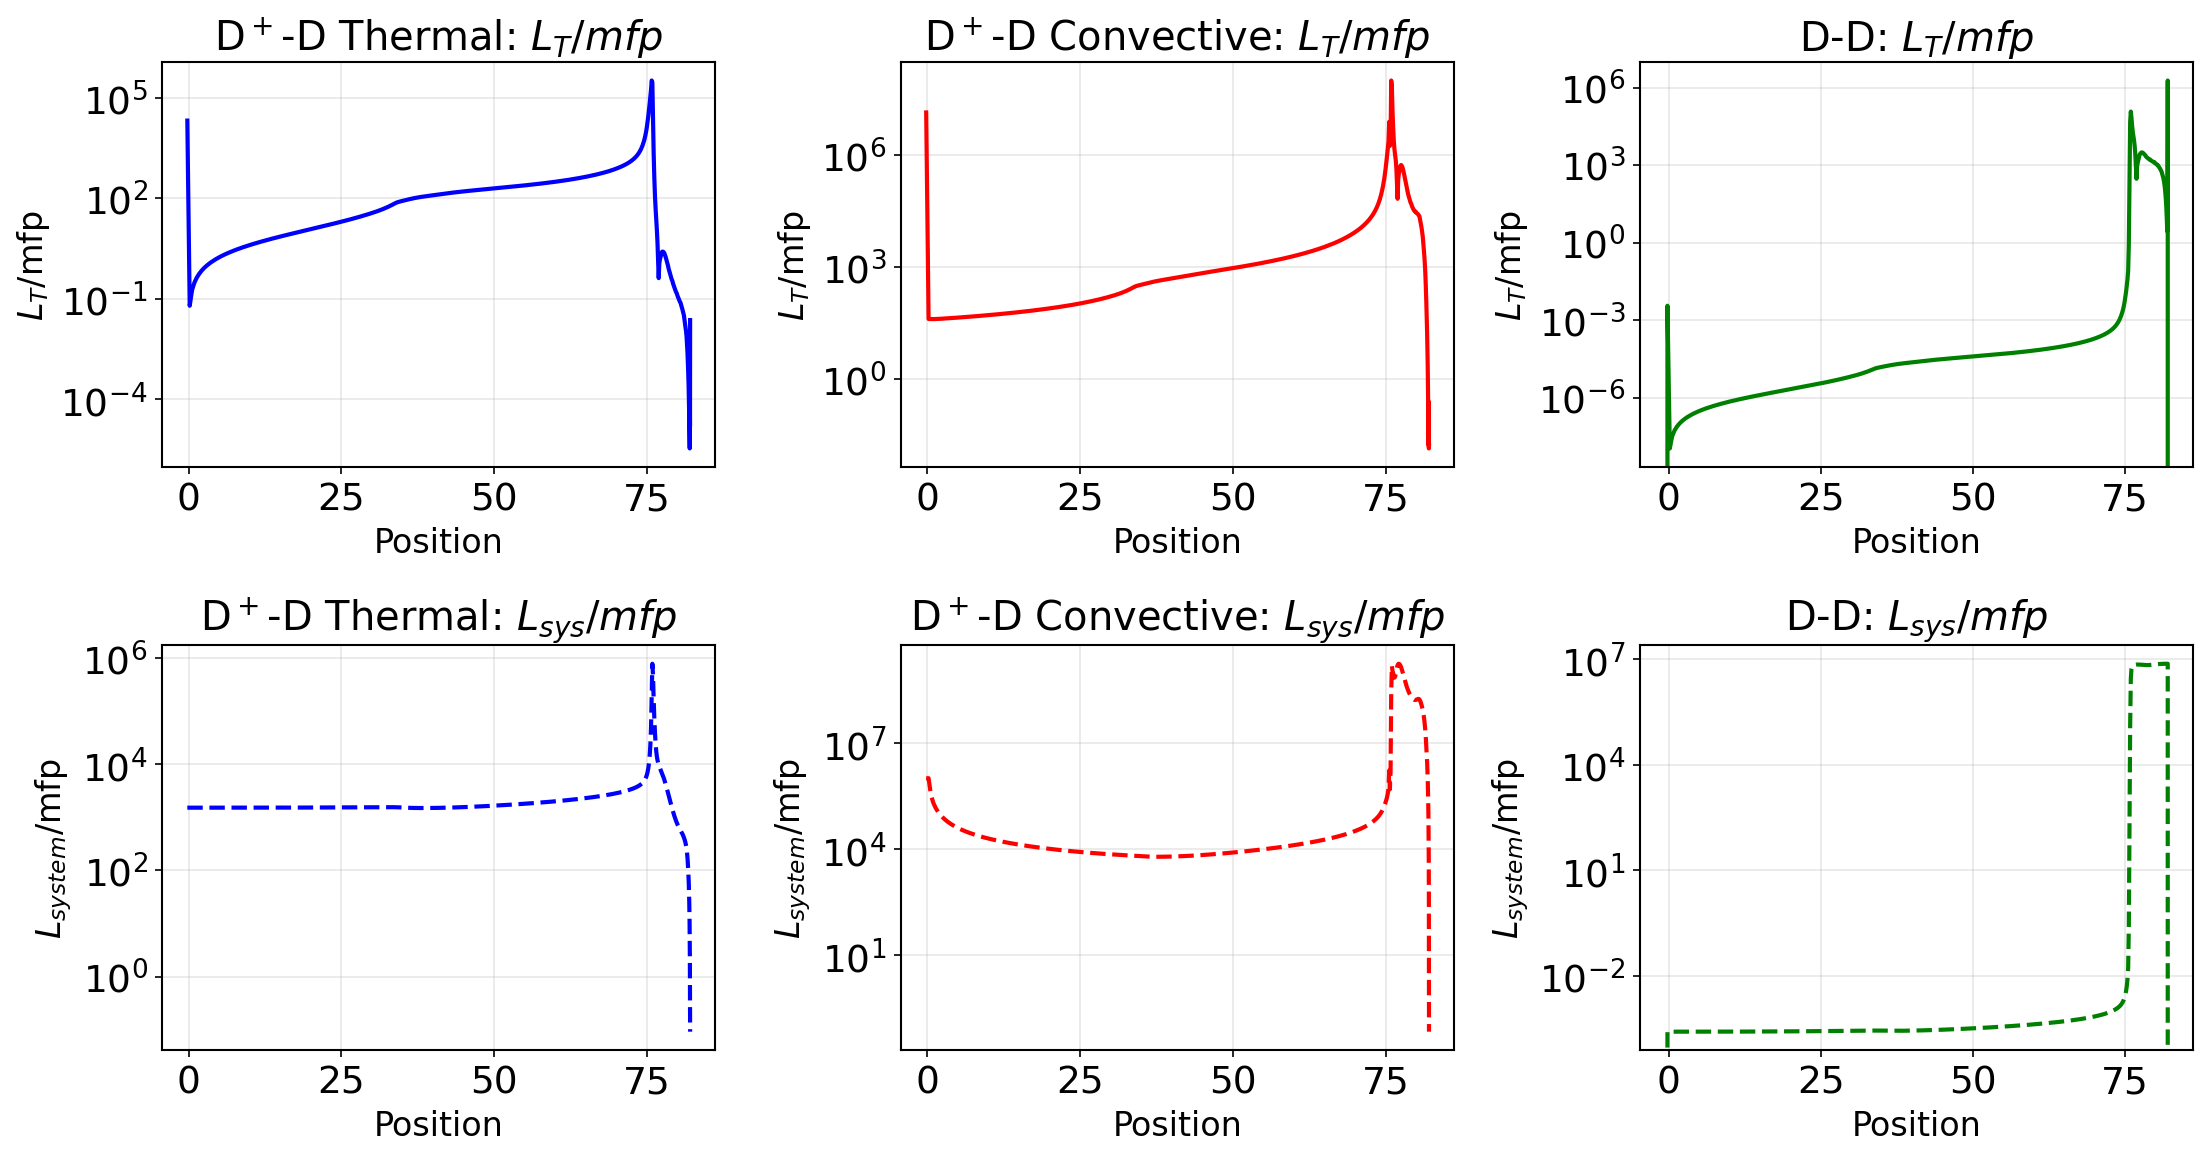

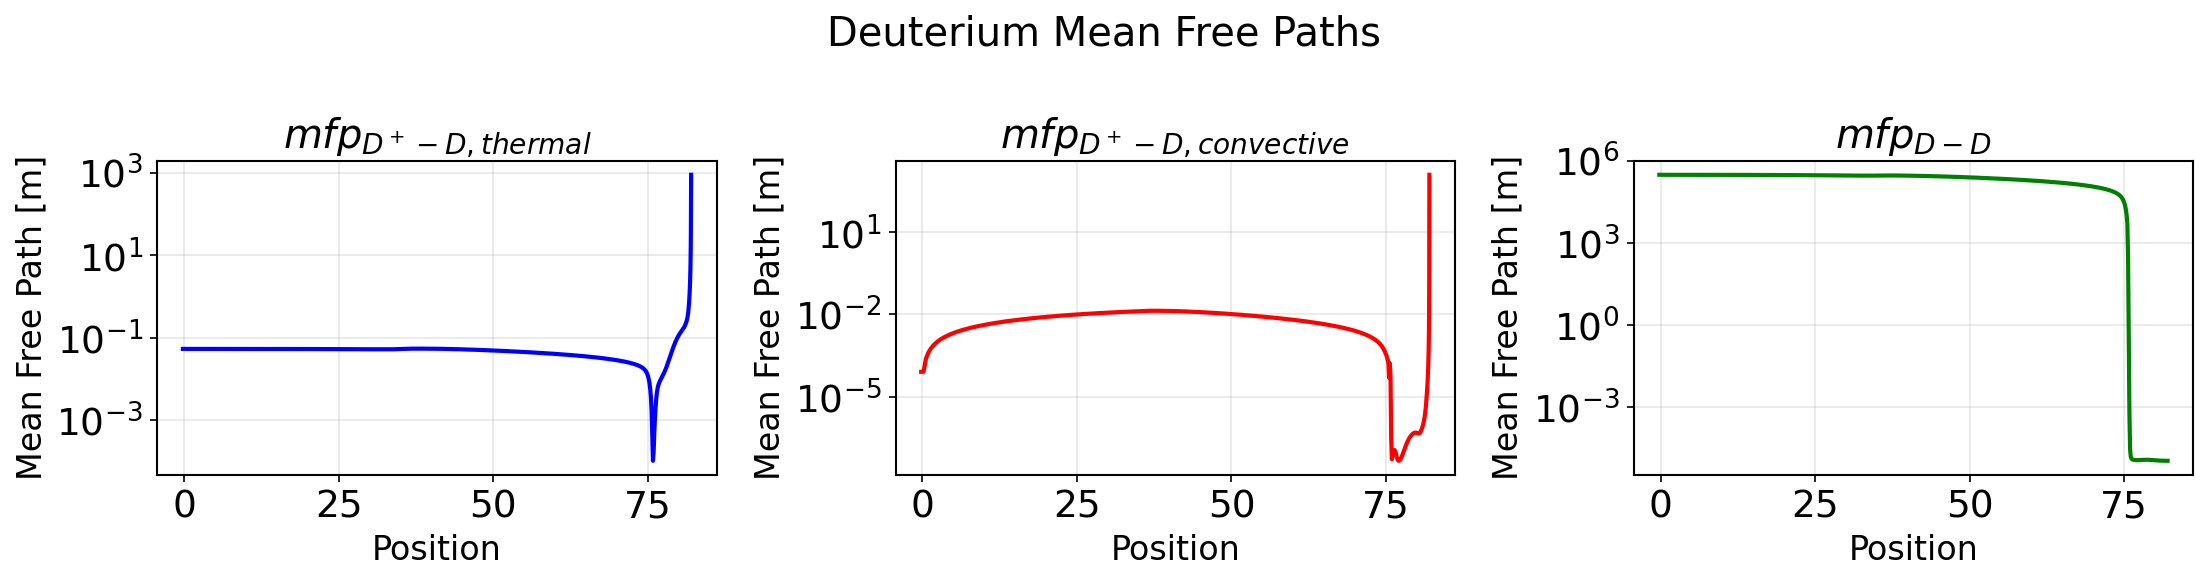

In [ ]:
for i in 

calculate_neutral_mfp_1d(ds)



In [50]:
def calculate_neutral_mfp_1d(ds, sigma_D_D=6e-19, time_index=0, multiplier=0):
    """
    Calculate 1D neutral mean free paths along spatial coordinate 'pos'
    For deuterium neutrals (D-D elastic collisions) and ion-neutral interactions
    
    Parameters:
    -----------
    ds : xarray Dataset
        Dataset containing plasma variables
    sigma_D_D : float, optional
        Deuterium-deuterium elastic collision cross-section in m^2
        Default: 6e-19 m^2 (ESTIMATED - should be validated experimentally)
    time_index : int, optional
        Time index to select for 1D analysis. Default: 0
    multiplier : float, optional
        Additional multiplier parameter (unused in current implementation)
        
        NOTE: This value is an estimate based on scaling from hydrogen.
        Direct experimental measurements of D-D atomic collision cross-sections
        at plasma-relevant energies are limited in the literature.
        
        To determine a better value:
        - Compare with measured neutral transport coefficients
        - Use kinetic theory with measured viscosity data
        - Validate against experimental neutral mean free path measurements
        - Typical range: 3e-19 to 1e-18 m^2
    """
    
    # Select specific time index for 1D analysis
    ds = ds.isel(t=time_index)  
    Ta = ds["Td"].values
    Ti = ds["Td+"].values
    Ne = ds["Ne"].values
    Na = ds["Nd"].values
    print(ds["Nd"].values[-2])
    Vi = ds["Vd+"]
    Va = ds["NVd"] / (ds["Nd"] * constants("mass_p")*2)

    # Calculate charge exchange collision frequency
    ln_sigmav = -18.5028
    Teff = (Ta + Ti)/2
    lnT = np.log(Teff)
    lnT_n = lnT.copy()

    for b in [0.3708409, 7.949876e-3, -6.143769e-4, -4.698969e-4, -4.096807e-4, 1.440382e-4, -1.514243e-5, 5.122435e-7]:
        ln_sigmav += b * lnT_n
        lnT_n *= lnT
        
    nu_cx = np.exp(ln_sigmav) * 1e-6 * Ne # convert from cm^3/s to m^3/s
    nu = nu_cx  # Only consider CX for ion-neutral collisions
    
    # Calculate thermal velocities
    v_thi = np.sqrt((ds["Td+"]*constants("q_e")) / (constants("mass_p")*2))
    v_thn = np.sqrt((ds["Td"]*constants("q_e")) / (constants("mass_p")*2))

    # Neutral-neutral collision frequency (Deuterium-Deuterium)
    # Using the adjustable cross-section parameter
    nu_nn = Na * sigma_D_D * np.sqrt(2) * v_thn  # Collision frequency [1/s]

    # For 1D case, velocities are just the values (no geometric transformation needed)
    Vi_spatial = Vi
    Va_spatial = Va

    # Calculate temperature gradient along 'pos' dimension
    L_T_spatial = ds["Td+"].differentiate('pos')  # Use xarray's differentiate along 'pos'

    # Calculate mean free paths
    mfp_thermal = (v_thi + v_thn) / nu  # Ion-neutral thermal MFP
    mfp_convective = abs(Vi_spatial - Va_spatial) / nu  # Ion-neutral convective MFP
    mfp_nn = 1 / (Na * sigma_D_D * np.sqrt(2))  # D-D elastic collision MFP

    # Calculate inverse Knudsen numbers (L_T/mfp)
    Kn_inv_thermal = abs(L_T_spatial) / mfp_thermal
    Kn_inv_convective = abs(L_T_spatial) / mfp_convective
    Kn_inv_nn = abs(L_T_spatial) / mfp_nn  # Deuterium-deuterium inverse Knudsen number
    
    # Get position coordinate
    pos = ds['pos']  # Your spatial coordinate
    
    # Create plots for all three LT/mfp comparisons
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)
    
    # D+-D Thermal: L_T/mfp
    axes[0].semilogy(pos, Kn_inv_thermal, linewidth=2, label='Hermes-3', color='black')
    axes[0].semilogy(pos, Kn_inv_thermal*1e-2, linewidth=2, label='SOLPS-ITER', color='blue')
    axes[0].axhline(100, color='r', linestyle='--')
    axes[0].set_title(r"D$^+$-D Thermal: $L_T/mfp$")
    axes[0].set_xlabel(r"$S_{\parallel}$")
    axes[0].set_ylabel("$L_T$/mfp")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # D+-D Convective: L_T/mfp
    axes[1].semilogy(pos, Kn_inv_convective, linewidth=2, label='Hermes-3', color='black')
    axes[1].semilogy(pos, Kn_inv_convective*1e-2, linewidth=2, label='SOLPS-ITER', color='blue')
    axes[1].axhline(100, color='r', linestyle='--')
    axes[1].set_title(r"D$^+$-D Convective: $L_T/mfp$")
    axes[1].set_xlabel(r"$S_{\parallel}$")
    axes[1].set_ylabel("$L_T$/mfp")
    # axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # D-D: L_T/mfp
    axes[2].semilogy(pos, Kn_inv_nn, linewidth=2, label='Hermes-3', color='black')
    axes[2].semilogy(pos, Kn_inv_nn*1e-2, linewidth=2, label='SOLPS-ITER', color='blue')
    axes[2].axhline(100, color='r', linestyle='--')
    axes[2].set_title(f"D-D: $L_T/mfp$")
    axes[2].set_xlabel(r"$S_{\parallel}$")
    axes[2].set_ylabel("$L_T$/mfp")
    # axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    fig.tight_layout()
    
    # Print cross-section info for transparency
    print(f"Used D-D collision cross-section: {sigma_D_D:.2e} m²")
    print("NOTE: D-D cross-section is an estimated value. For better accuracy:")
    print("1. Compare results with experimental neutral transport data")
    print("2. Adjust sigma_D_D parameter based on validation")
    print("3. Typical range: 3e-19 to 1e-18 m²")
    print("Usage: calculate_neutral_mfp_1d(ds, sigma_D_D=5e-19)")

8.782382749129223e+22
Used D-D collision cross-section: 6.00e-19 m²
NOTE: D-D cross-section is an estimated value. For better accuracy:
1. Compare results with experimental neutral transport data
2. Adjust sigma_D_D parameter based on validation
3. Typical range: 3e-19 to 1e-18 m²
Usage: calculate_neutral_mfp_1d(ds, sigma_D_D=5e-19)


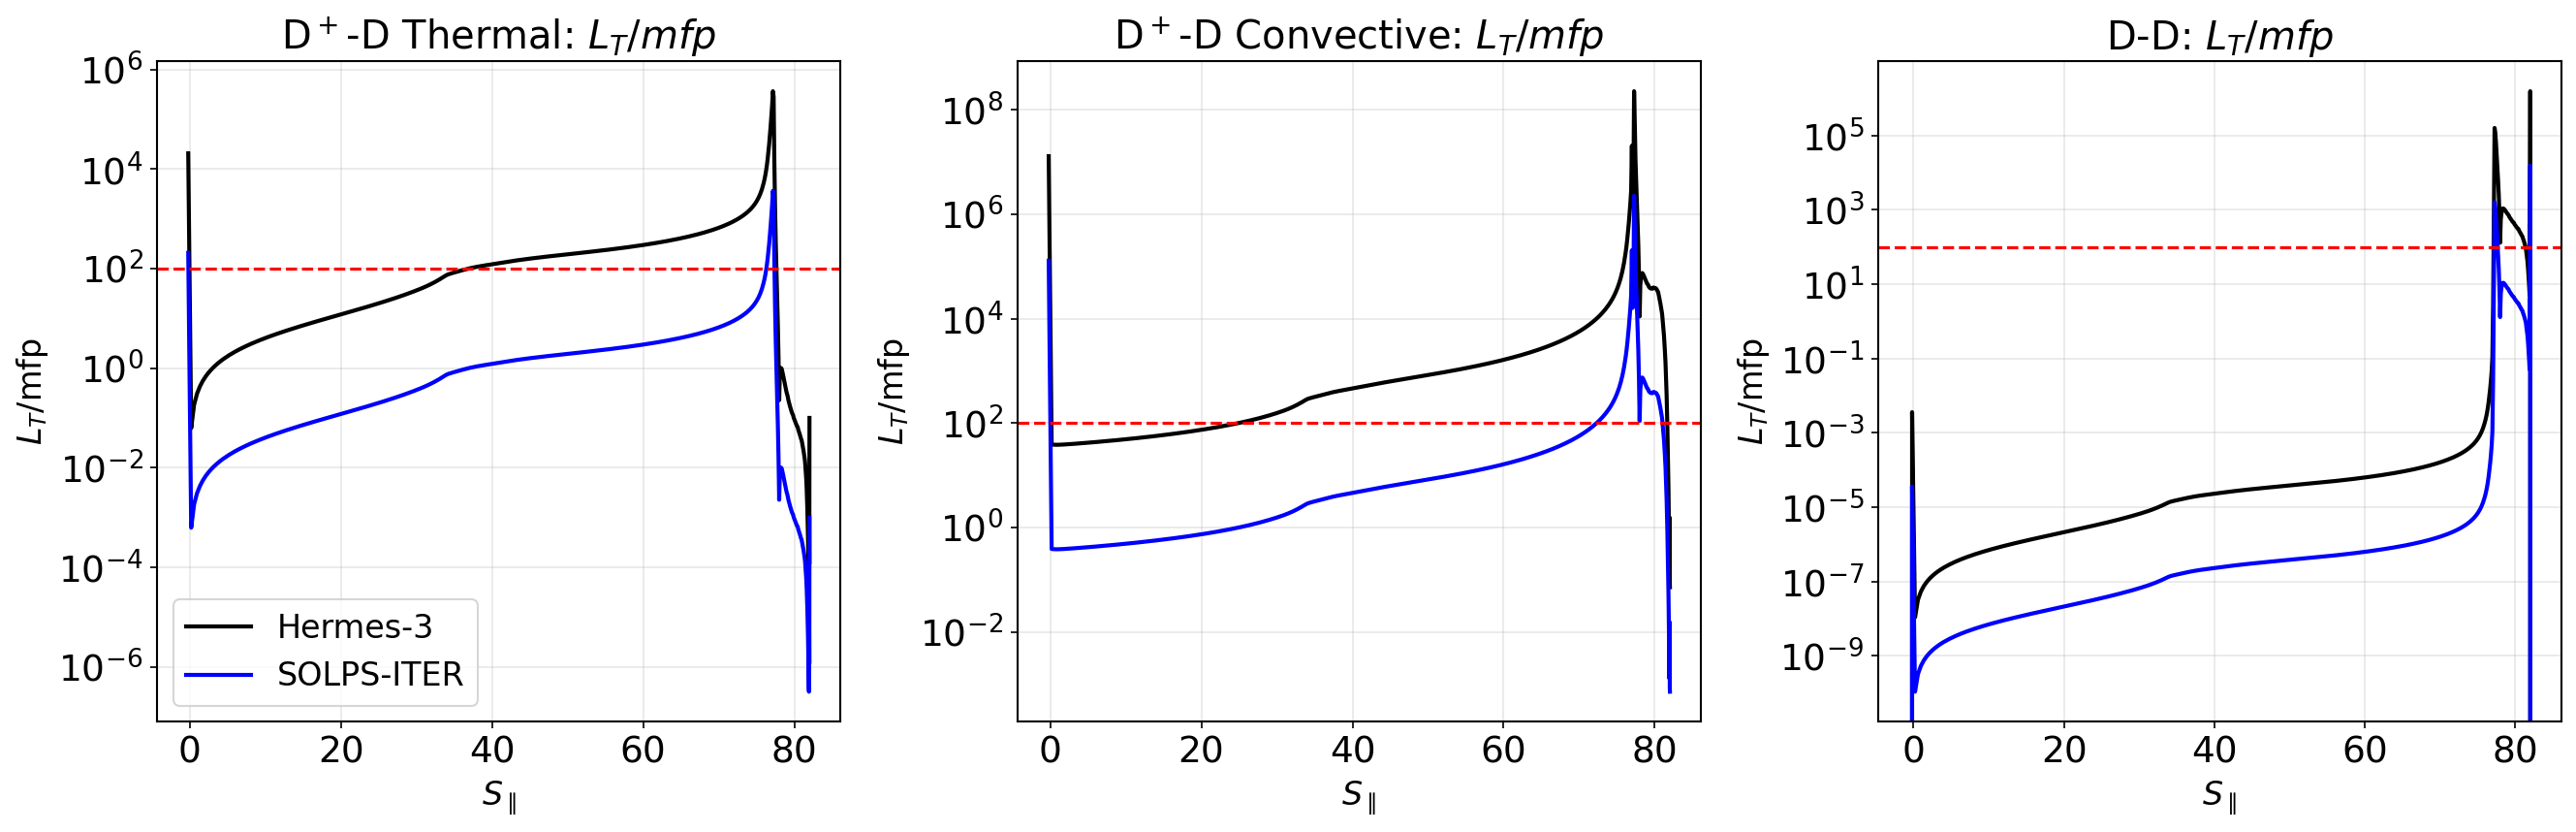

In [51]:
calculate_neutral_mfp_1d(ds, multiplier=1e-1)


In [12]:
print(ds['Nd'].values)

[[0.00000000e+00 3.76413996e+12 3.76413996e+12 ... 8.78238275e+22
  8.78238275e+22 0.00000000e+00]
 [0.00000000e+00 3.76413982e+12 3.76413982e+12 ... 8.78236255e+22
  8.78236255e+22 0.00000000e+00]
 [0.00000000e+00 3.76413968e+12 3.76413968e+12 ... 8.78234234e+22
  8.78234234e+22 0.00000000e+00]
 ...
 [0.00000000e+00 3.77540050e+12 3.77540050e+12 ... 1.05578765e+23
  1.05578765e+23 0.00000000e+00]
 [0.00000000e+00 3.77595287e+12 3.77595287e+12 ... 1.05243561e+23
  1.05243561e+23 0.00000000e+00]
 [0.00000000e+00 3.77653137e+12 3.77653137e+12 ... 1.04897291e+23
  1.04897291e+23 0.00000000e+00]]
